#1 : Import Libararies

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, LSTM, Dense, Dropout

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

#2 : Load Dataset

In [ ]:
# Load IMDB dataset
vocab_size = 12000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 25000
Test samples: 25000


#3 : Padding Sequence

In [ ]:
# Pad sequences to fixed length
max_len = 250

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

print("Shape after padding:", X_train.shape)

Shape after padding: (25000, 250)


#4 : GRU Model

In [ ]:
gru_model = Sequential()

gru_model.add(Embedding(vocab_size, 128, input_length=max_len))
gru_model.add(GRU(64))
gru_model.add(Dropout(0.5))
gru_model.add(Dense(1, activation='sigmoid'))

gru_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

gru_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#5 : Train GRU Model

In [ ]:
history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=6,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 175s 440ms/step - accuracy: 0.7830 - loss: 0.4472 - val_accuracy: 0.8566 - val_loss: 0.3367
Epoch 2/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 158s 405ms/step - accuracy: 0.9010 - loss: 0.2564 - val_accuracy: 0.8690 - val_loss: 0.3108
Epoch 3/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 146s 375ms/step - accuracy: 0.9402 - loss: 0.1671 - val_accuracy: 0.8789 - val_loss: 0.3190
Epoch 4/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 158s 404ms/step - accuracy: 0.9654 - loss: 0.1029 - val_accuracy: 0.8780 - val_loss: 0.3741
Epoch 5/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 145s 370ms/step - accuracy: 0.9798 - loss: 0.0636 - val_accuracy: 0.8729 - val_loss: 0.4519
Epoch 6/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 144s 369ms/step - accuracy: 0.9858 - loss: 0.0437 - val_accuracy: 0.8698 - val_loss: 0.5259


#6 : LSTM Model

In [ ]:
lstm_model = Sequential()

lstm_model.add(Embedding(vocab_size, 128, input_length=max_len))
lstm_model.add(LSTM(64))
lstm_model.add(Dropout(0.5))
lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#7 : Train LSTM Model

In [ ]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=6,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 141s 355ms/step - accuracy: 0.7945 - loss: 0.4415 - val_accuracy: 0.8489 - val_loss: 0.3580
Epoch 2/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 147s 377ms/step - accuracy: 0.8974 - loss: 0.2635 - val_accuracy: 0.8630 - val_loss: 0.3309
Epoch 3/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 138s 352ms/step - accuracy: 0.9317 - loss: 0.1843 - val_accuracy: 0.8607 - val_loss: 0.3315
Epoch 4/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 145s 361ms/step - accuracy: 0.9466 - loss: 0.1457 - val_accuracy: 0.8686 - val_loss: 0.3947
Epoch 5/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 138s 352ms/step - accuracy: 0.9411 - loss: 0.1602 - val_accuracy: 0.8625 - val_loss: 0.4206
Epoch 6/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 139s 354ms/step - accuracy: 0.9728 - loss: 0.0819 - val_accuracy: 0.8604 - val_loss: 0.4580


#8 : Accuracy Plot

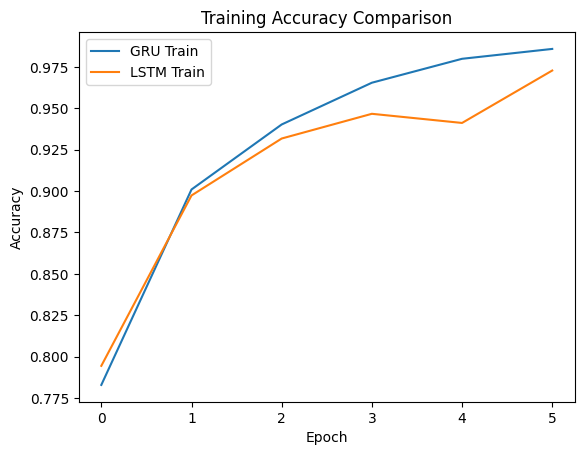

In [ ]:
plt.plot(history_gru.history['accuracy'], label='GRU Train')
plt.plot(history_lstm.history['accuracy'], label='LSTM Train')

plt.title("Training Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

#9 : Loss Plot

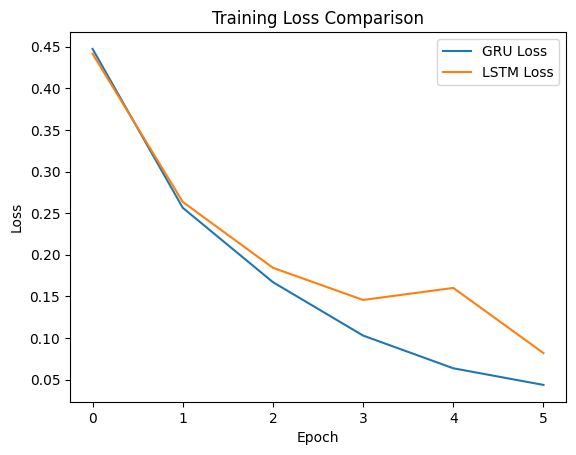

In [ ]:
plt.plot(history_gru.history['loss'], label='GRU Loss')
plt.plot(history_lstm.history['loss'], label='LSTM Loss')

plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

#10. Model Evaluation

In [ ]:
# Predictions using LSTM
y_pred = (lstm_model.predict(X_test) > 0.5)

print("Classification Report (LSTM):")
print(classification_report(y_test, y_pred))

782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step
Classification Report (LSTM):
              precision    recall  f1-score   support

           0       0.85      0.88      0.86     12500
           1       0.87      0.84      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



#11 : Confusion Matrix

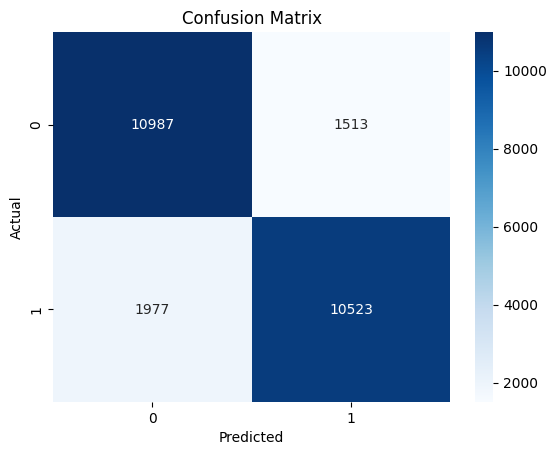

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()